In [5]:
import polars as pl
import matplotlib.pyplot as plt

In [6]:
events_dir = "../../data/raw/T-bank dataset full/T-ECD-small/dataset/small/marketplace/events"

In [7]:
events = (
    pl.scan_parquet(f"{events_dir}/*.pq", include_file_paths="path")
    .with_columns(
        pl.col("path")
          .str.extract(r"(\d+)\.pq", group_index=1)
          .cast(pl.Int32)
          .alias("day")
    )
    .sort("day")
    .drop("path")
)

In [8]:
events.collect_schema()

Schema([('timestamp', Duration(time_unit='us')),
        ('user_id', UInt64),
        ('item_id', String),
        ('subdomain', String),
        ('action_type', String),
        ('os', String),
        ('day', Int32)])

In [9]:
events.select(pl.len()).collect()

len
u32
130447117


In [10]:
users  = pl.scan_parquet('../../data/raw/T-bank dataset full/T-ECD-small/dataset/small/users.pq')
items  = pl.scan_parquet('../../data/raw/T-bank dataset full/T-ECD-small/dataset/small/marketplace/items.pq')
brands = pl.scan_parquet('../../data/raw/T-bank dataset full/T-ECD-small/dataset/small/brands.pq')

In [11]:
users.collect_schema()

Schema([('user_id', UInt64), ('socdem_cluster', UInt8), ('region', UInt8)])

In [12]:
users.select(pl.len()).collect()

len
u32
3500000


In [13]:
items.collect_schema()

Schema([('item_id', String),
        ('brand_id', UInt64),
        ('category', String),
        ('subcategory', String),
        ('price', Float64),
        ('embedding', Array(Float32, shape=(300,)))])

In [14]:
items.select(pl.len()).collect()

len
u32
2325409


In [15]:
brands.collect_schema()

Schema([('brand_id', UInt64), ('embedding', Array(Float32, shape=(300,)))])

In [16]:
brands.select(pl.len()).collect()

len
u32
24513


# Исследуем events

In [17]:
events.head().collect()

timestamp,user_id,item_id,subdomain,action_type,os,day
duration[μs],u64,str,str,str,str,i32
1082d 13h 41m 49s 577990µs,43648198,"""nfmcg_20114920""","""other""","""view""","""android""",1082
1082d 2s 185100µs,53883501,"""nfmcg_22430079""","""u2i""","""view""","""android""",1082
1082d 2s 235756µs,30999663,"""nfmcg_27387034""","""catalog""","""view""","""android""",1082
1082d 2s 661247µs,1651975,"""nfmcg_10287041""","""u2i""","""view""","""android""",1082
1082d 2s 670242µs,34508610,"""nfmcg_22003990""","""u2i""","""view""","""android""",1082


In [18]:
print(f'Уникальных пользователей: {events.select(pl.col('user_id').n_unique()).collect().item()}')
print(f'Уникальных айтемов: {events.select(pl.col('item_id').n_unique()).collect().item()}')

Уникальных пользователей: 1616763
Уникальных айтемов: 2325409


## Посмотрим на колонку со временем

In [19]:
print(events.collect_schema()['timestamp'])

Duration(time_unit='us')


In [20]:
events.select([
        pl.col('timestamp').min().alias('min_time'),
        pl.col('timestamp').max().alias('max_time'),
        (pl.col('timestamp').max() - pl.col('timestamp').min()).alias('diff') 
    ]).collect() 

min_time,max_time,diff
duration[μs],duration[μs],duration[μs]
1082d 89901µs,1308d 23h 59m 58s 175560µs,226d 23h 59m 58s 85659µs


Вывод: данные представлены за 226 (почти 227) дней

## Распределение по типам действий

In [21]:
events.group_by('action_type').agg(pl.len().alias('count')).sort('count', descending=True).collect()

action_type,count
str,u32
"""view""",126147783
"""click""",3772094
"""clickout""",485448
"""like""",41792


Самое частое действие - просмотр. Из значимых действий самое частое - click.

Вычислим распределение количества уникальных пользователей по типу событий

In [22]:
events.group_by('action_type').agg(pl.col('user_id').n_unique().alias('n_users')).sort('n_users', descending=True).collect()   

action_type,n_users
str,u32
"""view""",1615380
"""click""",548946
"""clickout""",136444
"""like""",13420


## Посмотрим распределение количества пользователей, событий и айтемов по дням

In [23]:
# События по дням
daily_activity = (
    events
    .group_by('day')
    .agg([
        pl.len().alias('events_count'),
        pl.n_unique('user_id').alias('daily_users'),
        pl.n_unique('item_id').alias('daily_items')
    ])
    .sort('day')
)

daily_activity.head(10).collect()

day,events_count,daily_users,daily_items
i32,u32,u32,u32
1082,500002,58321,42454
1083,511972,59857,42793
1084,534733,63260,49476
1085,494873,58721,46691
1086,519995,58989,50341
1087,494059,59691,48152
1088,459628,56500,46846
1089,516794,60715,52590
1090,520180,61562,49685


### Распределение по поверхностям (персональные рекомендации, каталог, поиск, похожие товары)

In [24]:
events.select(pl.col('subdomain').unique()).collect()

subdomain
str
"""search"""
null
"""other"""
"""u2i"""
"""catalog"""
"""i2i"""


In [25]:
events.group_by('subdomain').agg(pl.col('user_id').n_unique().alias('n_users')).sort('n_users', descending=True).collect()

subdomain,n_users
str,u32
"""u2i""",1433869
"""other""",1064301
"""catalog""",297170
"""i2i""",290908
"""search""",133127
null,13420


Из таблицы видно, что наибольшее количество взаимодействий пользователей с товаром произошло когда товар был показан в блоке персональных рекомендаций, сформированных специально для этого пользователя.

### Распределение количества уникальных пользователей по операционным системам

In [26]:
events.group_by('os').agg(pl.col('user_id').n_unique().alias('n_users')).sort('n_users', descending=True).collect()

os,n_users
str,u32
"""android""",1579243
"""ios""",1163114
"""other""",501257


Из таблицы видно, что чаще всего используемая платформа - android.

# Исследуем данные из таблицы users

In [27]:
users.head().collect()

user_id,socdem_cluster,region
u64,u8,u8
77309558,21,2
72517894,10,90
86699708,9,9
54241043,17,58
23591057,17,4


In [28]:
users.select(pl.col('socdem_cluster').n_unique()).collect().item()

22

In [29]:
users.select(pl.col('region').n_unique()).collect().item()

91

### Распределение по социо-демографическим кластерам (первые пять наиболее заполненнных)

In [30]:
users.group_by('socdem_cluster').agg(pl.col('user_id').n_unique().alias('n_users')).sort('n_users', descending=True).head().collect()

socdem_cluster,n_users
u8,u32
17,473629
20,420944
12,416287
9,340144
21,331140


### Распределение по регионам

In [31]:
users.group_by('region').agg(pl.col('user_id').n_unique().alias('n_users')).sort('n_users', descending=True).head().collect()

region,n_users
u8,u32
2,551358
60,249920
90,181623
18,137250
24,114992


# Исследуем данные из таблицы items

In [32]:
items.head().collect()

item_id,brand_id,category,subcategory,price,embedding
str,u64,str,str,f64,"array[f32, 300]"
"""nfmcg_10000001""",137356,null,null,6.06364,"[-0.070853, 0.03246, … 0.082178]"
"""nfmcg_10000012""",53389,null,null,0.960436,"[-0.091099, 0.043168, … 0.060287]"
"""nfmcg_1000002""",34153,"""Fashion Accessories, Tech Add-…","""Hats, Scarves, and Shawls""",-1.793113,"[-0.056533, 0.082878, … 0.037475]"
"""nfmcg_10000034""",39543,null,null,3.416755,"[-0.112588, 0.043333, … -0.001615]"
"""nfmcg_10000039""",82320,"""Fashion Accessories, Tech Add-…","""Jewelry and Costume Jewelry""",4.293433,"[-0.157201, 0.026234, … 0.013904]"


In [33]:
print(f'Количество уникальных категорий: {items.select(pl.col('category').n_unique()).collect().item()}')

Количество уникальных категорий: 23


In [34]:
# Посмотрим названия уникальных категорий
cats_df = items.select(pl.col('category').unique()).sort('category').collect().get_column('category') 

for category in cats_df:
    print(category)

None
Automotive Accessories, Spare Parts, and Car Care Products
Children's Products and Childcare Items
Cleaning Supplies and Everyday Household Items
Construction and Renovation Materials, Tools, and Equipment
Cosmetics, Personal Care, and Health Maintenance Products
Electronic Devices and Gadgets
Fashion Accessories, Tech Add-ons, and Style Enhancements
Foodstuffs and Beverages
Footwear of All Types
Hobby, Creative, and Leisure Products
Home Improvement and Countryside Retreat Essentials
Home/Office Furniture and Interior Decor
Household Electrical Appliances
Miscellaneous Goods (Uncategorized)
Office Supplies and Educational Materials
Outerwear, Casual Apparel, and Specialized Workwear
Personal and Intimate Care Products
Pet Supplies: Food, Accessories, and Grooming Products
Pharmaceuticals and Medical Supplies
Printed Media: Publications, Textbooks, and Fiction
Professional-Grade Tools and Industrial Equipment
Sports Equipment, Gear, and Outdoor Activity Accessories


In [35]:
items.group_by('category').agg(pl.col('item_id').n_unique().alias('n_items')).sort('n_items', descending=True).head().collect()

category,n_items
str,u32
null,966395
"""Miscellaneous Goods (Uncategor…",266146
"""Cosmetics, Personal Care, and …",188412
"""Fashion Accessories, Tech Add-…",167811
"""Outerwear, Casual Apparel, and…",153223


Больше всего айтемов представлены в категории "Miscellaneous Goods (Uncategorized)", следующая по количеству представленных айтемов категория "Cosmetics, Personal Care, and Health Maintenance Products".

In [36]:
print(f'Количество уникальных подкатегорий: {items.select(pl.col('subcategory').n_unique()).collect().item()}')

Количество уникальных подкатегорий: 193


Посмотрим количество уникальных айтемов в каждой категории

In [37]:
items.group_by('subcategory').agg(pl.col('item_id').n_unique().alias('n_items')).sort('n_items', descending=True).head().collect()

subcategory,n_items
str,u32
null,1233023
"""Jewelry and Costume Jewelry""",99751
"""Women's Clothing""",82778
"""Women's Footwear""",62212
"""Men's Clothing""",46759


Больше всего айтемов представлены в категории "Jewelry and Costume Jewelry", следующая по количеству представленных айтемов подкатегория "Women's Clothing".

In [38]:
subcats_df = items.select(pl.col('subcategory').unique()).sort('subcategory').collect().get_column('subcategory') 

for subcategory in subcats_df:
    print(subcategory)

None
3D Pens and Consumables
Accessories for Storing Small Items and Documents
Active Recreation and Travel Goods
Additional Automotive Products
Air Fresheners and Odor Neutralizers
Alcoholic Beverages and Related Products
Aquarium Fish and Reptile Supplies
Audio Systems and Equipment
Auto Repair Tools and Equipment
Automotive Oils and Chemical Products
Automotive Products and Accessories
Bags, Backpacks, and Travel Accessories
Bakery Products
Bedroom Furniture Sets
Beverage Preparation Appliances
Beverages and Drinks
Beverages: Tea, Coffee, Cocoa
Bicycles and Cycling Accessories
Bird Supplies
Body Care Cosmetics and Products
Body Skin Hygiene and Care Products
Boys' Children's Clothing
Boys' Children's Footwear
Built-In Household Appliances
Business Accessories
Cabinets and Storage Systems
Car Parts
Car Tires and Wheel Rims
Car Tools
Cat Supplies
Cheese Products
Children's Books and Literature
Children's Games and Toys
Children's Room Furniture and Accessories
Cleaning and Detergent P

# Связь категориальных переменных и количественной (price)

Посмотрим распределение цен по категориям

In [39]:
summary_by_category = (
    items
    .group_by('category')
    .agg(
        pl.col('price').max().alias('max_price'),
        pl.col('price').min().alias('min_price'),
        pl.col('price').mean().alias('mean_price'),
        pl.col('price').median().alias('median_price'),
    )
    .sort('max_price', descending=True)
)

summary_by_category.head().collect()

category,max_price,min_price,mean_price,median_price
str,f64,f64,f64,f64
"""Electronic Devices and Gadgets""",10.0,-7.94471,0.826219,0.5727
"""Miscellaneous Goods (Uncategor…",10.0,-10.0,0.212177,0.131004
"""Fashion Accessories, Tech Add-…",10.0,-10.0,1.67177,1.603516
null,10.0,-10.0,0.351831,0.290328
"""Home/Office Furniture and Inte…",8.568499,-8.178623,2.976257,2.950522


Посмотрим на распределение цен по подкатегориям

In [40]:
summary_by_subcategory = (
    items
    .group_by('subcategory')
    .agg(
        [pl.col('price').max().alias('max_price'),
        pl.col('price').min().alias('min_price'),
        pl.col('price').mean().alias('mean_price'),
        pl.col('price').median().alias('median_price'),
        ])
    .sort('max_price', descending=True)
)

summary_by_subcategory.head().collect()

subcategory,max_price,min_price,mean_price,median_price
str,f64,f64,f64,f64
null,10.0,-10.0,0.322503,0.248088
"""TV Panels and Components""",10.0,-6.07878,2.638179,3.011526
"""Electronic and Digital Goods""",10.0,-7.528531,-0.085731,-0.549872
"""Jewelry and Costume Jewelry""",10.0,-9.275899,1.963991,1.90285
"""Soft Sofas, Armchairs, and Int…",8.568499,-1.099695,4.600614,4.502553


Посмотрим на распределние цен в зависимости от бренда

In [41]:
summary_by_brand = (
    items
    .group_by('brand_id')
    .agg([
        pl.col('price').max().alias('max_price'),
        pl.col('price').min().alias('min_price'),
        pl.col('price').mean().alias('mean_price'),
        pl.col('price').median().alias('median_price'),
    ])
    .sort('max_price', descending=True)
)

In [42]:
summary_by_brand.head(10).collect()

brand_id,max_price,min_price,mean_price,median_price
u64,f64,f64,f64,f64
54857,10.0,-2.341586,3.975319,3.716136
70985,10.0,1.518843,4.409246,4.188179
82320,10.0,-0.235001,5.224603,5.016587
106609,10.0,-10.0,3.142555,3.32453
191971,10.0,-1.329518,4.196526,4.021201
21748,10.0,-7.473854,1.5505,1.38106
25232,10.0,-6.491091,1.769703,1.732438
117885,10.0,-7.94471,2.63037,2.593357
78943,8.568499,-2.746199,4.860934,5.146396


In [43]:
# Объединяем таблицу событий с данными о пользователях и присоединяем данные о товарах
# Возьмем только нужные колонки
summary_by_socdem = (
    events 
    .join(users, on='user_id', how='left')
    .join(items, on='item_id', how='left')
    .group_by('socdem_cluster')
    .agg([  
        pl.col('price').max().alias('max_price'),
        pl.col('price').min().alias('min_price'),
        pl.col('price').mean().alias('mean_price'),
        pl.col('price').median().alias('median_price'),
    ])
    .sort('max_price', descending=True)
    .head(10) 
    .collect() 
)

summary_by_socdem

socdem_cluster,max_price,min_price,mean_price,median_price
u8,f64,f64,f64,f64
null,10.0,-8.656934,1.939032,1.989792
12,10.0,-10.0,2.267044,2.118503
18,10.0,-10.0,1.53093,1.644707
0,10.0,-10.0,1.645808,1.709356
21,10.0,-10.0,2.392081,2.222444
9,10.0,-10.0,1.494064,1.556649
7,10.0,-10.0,1.962604,1.864164
1,10.0,-10.0,1.898927,1.863689
10,10.0,-10.0,1.546006,1.604669


# Посмотрим на данные из таблицы brands

In [44]:
brands.head(10).collect()

brand_id,embedding
u64,"array[f32, 300]"
4,null
34,null
45,null
46,null
51,null
59,null
73,null
97,null
128,null


# Анализ пропусков

## Пропущенные значения в датасете users (совпадает во всех доменах)

In [45]:
users.select(pl.all().null_count()).collect()

user_id,socdem_cluster,region
u32,u32,u32
0,5153,58917


In [46]:
missing_rates = (
    users.select(
        (pl.all().null_count() / pl.len()) 
    )
    .collect()
)

missing_rates

user_id,socdem_cluster,region
f64,f64,f64
0.0,0.001472,0.016833


Возможные причины возникновения пропусков:

* Необязательные поля при регистрации

* Система не смогла определить местоположение пользователя, возможно пользователь не дал разрешение на определение местоположения

* Технические ошибки при сборе данных

In [61]:
# проверим дубликаты
users.select(
    pl.struct(pl.all()).is_duplicated().sum().alias("n_duplicates")
).collect()

n_duplicates
u32
0


In [67]:
print(f'Минимальное значение в колонках socdem_cluster и region соответвенно: {users.select('socdem_cluster').min().collect().item()} и {users.select('region').min().collect().item()}')

Минимальное значение в колонках socdem_cluster и region соответвенно: 0 и 0


### Возможная стратегия работы с пропусками

Процент пропусков очень мал. 

* Технически можно удалить строки с пропущенными значениями в таблице users_df. Но тогда мы должны будем удалить этих пользователей из таблицы events_df, которую мы будем использовать для посторения матрицы взаимодействий и уже на этой основе строить прогноз. 

* Колонки socdem_cluster и region это категориальные данные, закодированные числами. Можно заполнить пропущенные значения специальным зарезервированным числом, которое не встречается среди реальных кодов регионов и кластеров. Таким образом, мы сохраним всю историю взаимодействий c этими айтемами в events_df. Можно использовать число -1, так как минимальное значение в указанных колонках равно ноль.

## Пропущенные значения в items_df

In [68]:
items.null_count().collect()

item_id,brand_id,category,subcategory,price,embedding
u32,u32,u32,u32,u32,u32
0,0,966395,1233023,2882,73


In [69]:
items.select(pl.all().null_count() / pl.len()).collect()

item_id,brand_id,category,subcategory,price,embedding
f64,f64,f64,f64,f64,f64
0.0,0.0,0.415581,0.530239,0.001239,0.000031


### Возможные причины возникновения пропусков

* Для `category` и `subcategory` - товар могли добавить в базу данных, но еще не успели присвоить ему категорию.

* Некоторые товары могут не подходить ни под одну из существующих категорий, и поле остается пустым.

* Поставшики прислали неполную информацию.

* Для `price` - это могут быть товары не для продажи, а, например, промо-материалы.

* Некоторые товары могут не иметь публичной цены, а она узнается по запросу.

* Часть комплекта: товар может продаваться только в составе набора, и у него нет индивидуальной цены.

### Возможная стратегия работы с пропусками

* в колонках `category` и `subcategory` (категориальные данные) заменить на 'unknown'.Таким образом, мы сохраняем всю его ценную историю взаимодействий в `events_df`.
  
* Это лучше, чем заполнять самой частой категорией, так как это может внести смещение в данные.

* Колонка `price`. Можно заполнить нулем, если мы можем предположить, что товар, например, акционный, бесплатный. Но это частный случай и у нас нет данных для выдвижения такого предположения. Лучше заполнить медианой. Медиана более устойчива к выбросам, поэтому она лучше отражает "типичную" цену.

## Пропущенные значения в events

In [70]:
events.null_count().collect()

timestamp,user_id,item_id,subdomain,action_type,os,day
u32,u32,u32,u32,u32,u32,u32
0,0,0,41792,0,0,0


In [73]:
events.select(pl.all().null_count() / pl.len()).collect()

timestamp,user_id,item_id,subdomain,action_type,os,day
f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.00032,0.0,0.0,0.0


### Возможная стратегия работы с пропусками

* в колонке `subdomain` заменить на 'unknown'.

* удалить, так как пропуски - всего 0.03%

## Пропущенные значения в brands (совпадает во всех доменах)

In [74]:
brands.null_count().collect()

brand_id,embedding
u32,u32
0,17954


In [82]:
print(f'Доля пропущенных значений в колонке embedding:  {(brands.select(pl.col('embedding').null_count() / pl.len()).collect().item()):.4f}')

Доля пропущенных значений в колонке embedding:  0.7324


Более 73% брендов не имеют эмбеддинга. Возможные причины:

* Пропущенные эмбеддинги могут говорить о холодных брендах, а могут и не говорить.

* Эмбеддинги могут пересчитывать не в реальном времени, а, например, раз в неделю. Пропуски могут соответствовать брендам, которые были добавлены после последнего обновления и еще ждут своей очереди на обработку.

### Возможная стратегия работы с пропусками

* Можно удалить колонку

* Можно оставить и попробовать что-то сделать в рамках нейросетевой модели

* Можно посмотреть временную связь на всех данных


**Заметка про работу с холодным стартом на будущее** (из лекция https://vkvideo.ru/video-123851409_456239391?list=ln-rYpN16j7stPziuqnla)

* Рекомендовать популярные

* Построить модель на соцдеме или других данных (Например, женщинам рекомендовать женскую одежду, мужчинам мужскую и тд). То есть построить набор популярных товаров, характерных для этого соцдема.

* Провести онбординг (некоторые сервисы при регистрации спрашивают, укажите что вам нравится)

# Анализ до заполнения пропусков

### Анализ users

In [86]:
print(f'Уникальных пользователей: {users.select(pl.col('user_id').n_unique()).collect().item()}')
print(f'Уникальных регионов: {users.select(pl.col('region').n_unique()).collect().item()}')
print(f'Уникальных социо-демографических кластеров: {users.select(pl.col('socdem_cluster').n_unique()).collect().item()}')

Уникальных пользователей: 3500000
Уникальных регионов: 91
Уникальных социо-демографических кластеров: 22


In [62]:
# Посмотрим, сколько пользователей в каждом регионе
users['region'].value_counts().sort('count', descending=True)

region,count
u8,u32
2,551358
60,249920
90,181623
18,137250
24,114992
…,…
65,1687
30,1125
69,915


In [90]:
# Посмотрим, сколько пользователей в каждом кластере
users.group_by('socdem_cluster').len().sort('len', descending=True).collect()

socdem_cluster,len
u8,u32
17,473629
20,420944
12,416287
9,340144
21,331140
…,…
8,5825
null,5153
3,3900


### Анализ items

In [91]:
dist_without_na = items.select("price").collect().describe()

dist_without_na

statistic,price
str,f64
"""count""",2.322527e6
"""null_count""",2882.0
"""mean""",0.489804
"""std""",2.455037
"""min""",-10.0
"""25%""",-1.219739
"""50%""",0.425758
"""75%""",2.194017
"""max""",10.0


* Cреднее значение и медиана близки друг к другу, значит распределение относительно симметричное.

* Имеет место правостороннее распределение с положительной асимметрией, где среднее значение 0.49 и медиана 0.43 смещены в положительную область, что указывает на преобладание цен выше условного нуля. Четверть значений остаются отрицательными (25-й перцентиль: -1.22), при этом основная масса данных сосредоточена в интервале от -1.22 до 2.19. 

Применим метод z-score для поиска значений, которые сильно отличаются от основной массы

In [96]:
result = items.select(
    pl.col('price').drop_nulls()
).with_columns(
    z_score = (pl.col('price') - pl.col('price').mean()) / pl.col('price').std()
).filter(pl.col('z_score').abs() > 3)

In [97]:
outliers_df = result.collect()

In [98]:
n_outliers = outliers_df.height
print("Найдено значений, сильно отличающихся от основной массы:", n_outliers)
print(outliers_df.head())

Найдено значений, сильно отличающихся от основной массы: 5736
shape: (5, 2)
┌──────────┬──────────┐
│ price    ┆ z_score  │
│ ---      ┆ ---      │
│ f64      ┆ f64      │
╞══════════╪══════════╡
│ 7.946068 ┆ 3.037129 │
│ 8.471466 ┆ 3.251137 │
│ 7.861344 ┆ 3.002619 │
│ 8.575839 ┆ 3.293651 │
│ 8.381851 ┆ 3.214635 │
└──────────┴──────────┘


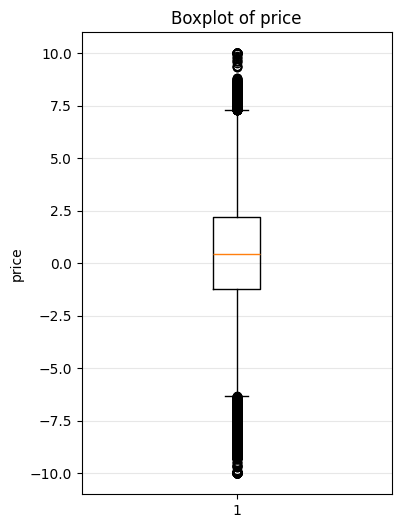

In [99]:
import matplotlib.pyplot as plt

price = items.select(pl.col("price").drop_nulls()).collect().get_column("price")

plt.figure(figsize=(4, 6))
plt.boxplot(price, vert=True, showfliers=True)
plt.ylabel('price')
plt.title('Boxplot of price')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Покажем варианты заполнения пропусков

## Обработка users
В таблице users_df заполняем пропуски в закодированных категориальных признаках region и socdem_cluster числом -1. Мы это можем сделать, так как минимальные значения этих признаков равны нулю.

In [100]:
users = users.with_columns(
    pl.col('region').fill_null(-1)
)

In [101]:
users = users.with_columns(
    pl.col('socdem_cluster').fill_null(-1)
)

In [103]:
print('Пропуски в users_df после обработки:')
users.null_count().collect()

Пропуски в users_df после обработки:


user_id,socdem_cluster,region
u32,u32,u32
0,0,0


## Обработка items

In [104]:
items = items.with_columns(pl.col('category').fill_null('unknown'))
items = items.with_columns(pl.col('subcategory').fill_null('subunknown'))

In [105]:
items.null_count().collect()

item_id,brand_id,category,subcategory,price,embedding
u32,u32,u32,u32,u32,u32
0,0,0,0,2882,73


In [108]:
# Рассчитываем медианную цену
median_price = items.select(pl.col('price').median()).collect().item()
print(f'Медианная цена для заполнения пропусков: {median_price}')

Медианная цена для заполнения пропусков: 0.42575823138244323


In [111]:
items.select(pl.col('price').min()).collect().item()

-10.0

В признаке price присутствуют отрицательные значения. Это не выбросы. В описании дата сета price - представляет собой денежную стоимость взаимодействия. Цены в каталогах переведены в промежуток от −10 до 10. 

In [112]:
# Заполняем пропуски в цене медианой
items = items.with_columns(pl.col('price').fill_null(median_price))

In [113]:
print("Пропуски в items_df после обработки:")
items.null_count().collect()

Пропуски в items_df после обработки:


item_id,brand_id,category,subcategory,price,embedding
u32,u32,u32,u32,u32,u32
0,0,0,0,0,73


## Обработка brands_df

Пропуски в embedding пока не трогаем. 

## Анализ цен  из items после заполнения пропусков

In [114]:
dist = items.select('price').collect().describe()

dist

statistic,price
str,f64
"""count""",2.325409e6
"""null_count""",0.0
"""mean""",0.489725
"""std""",2.453516
"""min""",-10.0
"""25%""",-1.2174
"""50%""",0.425758
"""75%""",2.191838
"""max""",10.0


* Из таблицы видно, что среднее значение и медиана близки друг к другу, значит распределение относительно симметричное.

* Имеет место правостороннее распределение с положительной асимметрией, где среднее значение 0.49 и медиана 0.43 смещены в положительную область, что указывает на преобладание цен выше условного нуля.

* Четверть значений остаются отрицательными (25-й перцентиль: -1.22), при этом основная масса данных сосредоточена в интервале от -1.22 до 2.19.

In [115]:
# Сравним с распределением цен до заполнения пропусков
dist_without_na

statistic,price
str,f64
"""count""",2.322527e6
"""null_count""",2882.0
"""mean""",0.489804
"""std""",2.455037
"""min""",-10.0
"""25%""",-1.219739
"""50%""",0.425758
"""75%""",2.194017
"""max""",10.0


Заполнение пропусков медианой прошло успешно и оказало минимальное, предсказуемое влияние на общую картину распределения цен 

# Можно еще посмотреть самых активных пользователей

In [119]:
# Например, по клику
top_click_users = (
    events
    .filter(pl.col('action_type') == 'click')
    .group_by('user_id')
    .len()
    .sort('len', descending=True)
    .head(20)
)

top_click_users.collect()

user_id,len
u64,u32
72689451,379
40921409,301
62263819,292
73451431,284
71279941,269
…,…
65306762,221
3996560,220
59611388,217


# Для исследования взаимосвязи между категориальными переменными вычислим V-меру Крамера

V-мера Крамера вычисляется по формуле:

$$
V = \sqrt{\frac{\chi^2}{n \cdot (k-1)}}
$$

In [131]:
items  = pl.scan_parquet('../../data/raw/T-bank dataset full/T-ECD-small/dataset/small/marketplace/items.pq')
users  = pl.scan_parquet('../../data/raw/T-bank dataset full/T-ECD-small/dataset/small/users.pq')

In [132]:
import scipy.stats as stats
import numpy as np

import polars as pl
import numpy as np
import scipy.stats as stats

def calculate_cramers_v_polars(lf, col_a, col_b):
    counts_lazy = (
        lf.select([col_a, col_b])
          .drop_nulls()
          .group_by([col_a, col_b])
          .len()  
    )
    
    counts_df = counts_lazy.collect()
    
    if counts_df.is_empty():
        return 0.0

   
    crosstab = (
        counts_df
        .pivot(values="len", index=col_a, on=col_b)
        .fill_null(0)
    )
    
    
    data_matrix = crosstab.drop(col_a).to_numpy()
    
    
    chi2, p, dof, expected = stats.chi2_contingency(data_matrix)
    
    n = data_matrix.sum()
    min_dim = min(data_matrix.shape) - 1
    
    if min_dim <= 0 or n == 0:
        return 0.0
        
    return np.sqrt(chi2 / (n * min_dim))


In [133]:
v_cat_sub = calculate_cramers_v_polars(items, "category", "subcategory")
print(f"V Крамера (Категория vs Подкатегория): {v_cat_sub:.4f}")

V Крамера (Категория vs Подкатегория): 1.0000


Вывод: признаки category и subcategory полностью зависимы. Скорее всего значение подкатегории полностью предсказывает категорию. Поэтому лучше удалить признак category и оставить subcategory.

In [134]:
v_brand_cat = calculate_cramers_v_polars(items, "brand_id", "category")
print(f"V Крамера (Бренд vs Категория): {v_brand_cat:.4f}")

V Крамера (Бренд vs Категория): 0.4833


Вывод: есть умеренная связь.

In [135]:
v_brand_subcat = calculate_cramers_v_polars(items, "brand_id", "subcategory")
print(f"V Крамера (Бренд vs Подкатегория): {v_brand_subcat:.4f}")

V Крамера (Бренд vs Подкатегория): 0.2661


Вывод: связь умеренная, ближе к слабой. Связь слабее, чем с связь бренда с категорией. 

In [136]:
v_socdem_region = calculate_cramers_v_polars(users, "socdem_cluster", "region")
print(f"V Крамера (Соцдем кластер vs Регион): {v_socdem_region :.4f}")

V Крамера (Соцдем кластер vs Регион): 0.0357
